In [2]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

import hubble_fit
from hubble_fit import *

from hubble_utils import *
from hubble_likelihood import *
from hubble_plotting import *
from hubble_model import *
from hubble_completeness import *

CPU Num Cores: 30


In [3]:
df_pantheon, _sna_LogdetCov, _sna_L, _sna_Lower = load_pantheon_data()
df_agn = load_agn_data("results/data/aug29_chisq_nobwb_carma21_qscpu_N20w4000s1000t8c4_fittedm2500_diffalpha.h5")
df_agn = df_agn[:4000]


Loading Pantheon+ supernova data...
Loading SN covariance matrix...
Cholesky factorization successful. Data loaded. 
Loading quasar data...


Reading quasars from HDF5: 100%|██████████| 13160/13160 [00:30<00:00, 432.18it/s]


Number of quasars loaded: 13160
Number of quasars with 0 < z <= 1.0: 3204
Number of quasars with z > 3: 405
Highest redshift quasar: 4.455935435869128
Columns with NaNs: ['apparent_mag_g', 'apparent_mag_g_err', 'apparent_mag_i', 'apparent_mag_i_err', 'apparent_mag_i_obs', 'apparent_mag_r', 'apparent_mag_r_err', 'apparent_mag_u', 'apparent_mag_u_err', 'apparent_mag_z', 'apparent_mag_z_err', 'log_amp_delta_blr_g', 'log_amp_delta_blr_g_err', 'log_amp_delta_blr_u', 'log_amp_delta_blr_u_err', 'log_jitter_g', 'log_jitter_g_err', 'log_jitter_u', 'log_jitter_u_err', 'log_lag_blr_g', 'log_lag_blr_g_err', 'log_lag_blr_u', 'log_lag_blr_u_err', 'log_sigma_band_g', 'log_sigma_band_g_err', 'log_sigma_band_u', 'log_sigma_band_u_err', 'log_tau_band_g_RF', 'log_tau_band_g_RF_err', 'log_tau_band_u_RF', 'log_tau_band_u_RF_err', 'mags_mean_g', 'mags_mean_u', 'mean_g', 'mean_g_err', 'mean_u', 'mean_u_err']
Excluding 0 objects by object_id exclusion list
Cut on log_tau_UV_RF: 108 objects removed
Cut on redc

In [4]:
sampler, flat_samples, model_labels, dmag_corr, logZ, logZerr = hubble_fit.run_single(df_agn, df_pantheon, _sna_L, _sna_Lower, _sna_LogdetCov, 
                    "FlatwCDM", completeness=True, use_full_cov=True, 
                    N=None, resume="results/dynesty_checkpoint/diffalpha/dynesty_checkpoint_FlatwCDM_joint_test.save", 
                    only_sna=False, speed="test")

Running sampling with 8 parameters for cosmological model: FlatwCDM
object_id for m2500 > 25: ['024629.37+000735.3' '024447.66+005700.4' '024414.87-011005.6'
 '024410.25-005717.4' '023754.67+002645.1' '023702.66+005745.2'
 '022728.66-005932.4' '020929.83-005602.6' '015551.57+000329.1'
 '015347.56-000027.5' '014533.38-002932.0' '014448.59+005133.8'
 '014312.55+010420.3' '014120.33+002510.2' '013932.36+000720.7'
 '013745.07+005524.0']
Best alpha selected by CV: 0.07054802310718646
a (slope on mag_i)      = 1.039416 ± 0.005532
b (slope on alpha)      = 1.206538 ± 0.012007
d (quad term on mag_i)  = 0.016247 ± 0.002196
c_pivot (at pivots)     = 22.527476 ± 0.005565
c (intercept)           = -4.255889
R^2                     = 0.8989
Scatter (σ)             = 0.312 mag
Using mag range: 16.00 to 26.00
Using z range: 0.05 to 4.96
log tau UV RF mean: 2.7345
log tau UV RF pivot (weighted): 2.6334
log sigma0 mean: -0.7333
log sigma0 pivot (weighted): -0.7210
alpha_nu mean: -0.7108
alpha_nu pivot 

/opt/miniconda3/envs/jaxcpu/lib/python3.13/site-packages/numpy/_core/_methods.py:51: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


[WARNING] Resuming from checkpoint file...
Resuming from checkpoint file: results/dynesty_checkpoint/diffalpha/dynesty_checkpoint_FlatwCDM_joint_test.save

Bayesian evidence logZ = 4077.24 ± 0.45

Highest-weight (posterior) sample:
  idx: 4281
  logl: 4098.658588881739
  weight: 0.0019628999711345397
  (preview) integrals[:10]: [0.03393777 0.10287974 0.07068407 0.07204092 0.03165635 0.1036964
 0.08592309 0.0828021  0.09047054 0.08809675]

Dynesty results stats:
  samples shape: (5016, 8)
  blobs shape: (5016, 2, 4000)
  weights max: 0.0019628999711345397
  effective samples (ESS): 766.0018349141866
  resampled samples shape: (5016, 8)
  resampled blobs shape: (5016, 2, 4000)

Median parameters (equal-weight posterior):
[-19.24955644 -21.3441997    6.87409511  -2.47344177  -0.26677275
  73.51417122   0.43243013  -1.31375344]
Saving plots to  plots/hubble//FlatwCDM_joint_test
Plotting full dynesty corner...
Plotting predicted vs actual M2500...
Plotting Hubble diagram...


/home/dutra/dev/eztaox/qvc/hubble_plotting.py:628: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Outliers with residuals > 4:
	z: 0.83 | object_id: 1389193 | SDSS: 024717.29-005205.7 | RA: 41.82207 | DEC: -0.86825 | Residual: 4.6
	z: 2.76 | object_id: 1390664 | SDSS: 024328.86+003831.0 | RA: 40.87026 | DEC: 0.64196 | Residual: -4.3
	z: 0.73 | object_id: 1392713 | SDSS: 023754.67+002645.1 | RA: 39.47782 | DEC: 0.44588 | Residual: 4.5
	z: 0.59 | object_id: 1394980 | SDSS: 023121.78-000747.0 | RA: 37.84076 | DEC: -0.12975 | Residual: 6.0
	z: 1.53 | object_id: 1395413 | SDSS: 023014.79+011049.7 | RA: 37.56164 | DEC: 1.18048 | Residual: 4.0
	z: 0.49 | object_id: 1395787 | SDSS: 022914.13+010741.7 | RA: 37.30891 | DEC: 1.12826 | Residual: 4.7
	z: 1.13 | object_id: 1396458 | SDSS: 022728.66-005932.4 | RA: 36.86943 | DEC: -0.99234 | Residual: 4.6
	z: 0.38 | object_id: 1397617 | SDSS: 022414.66+002415.5 | RA: 36.06109 | DEC: 0.40431 | Residual: 4.7
	z: 0.60 | object_id: 1397913 | SDSS: 022324.21+003251.8 | RA: 35.85091 | DEC: 0.547

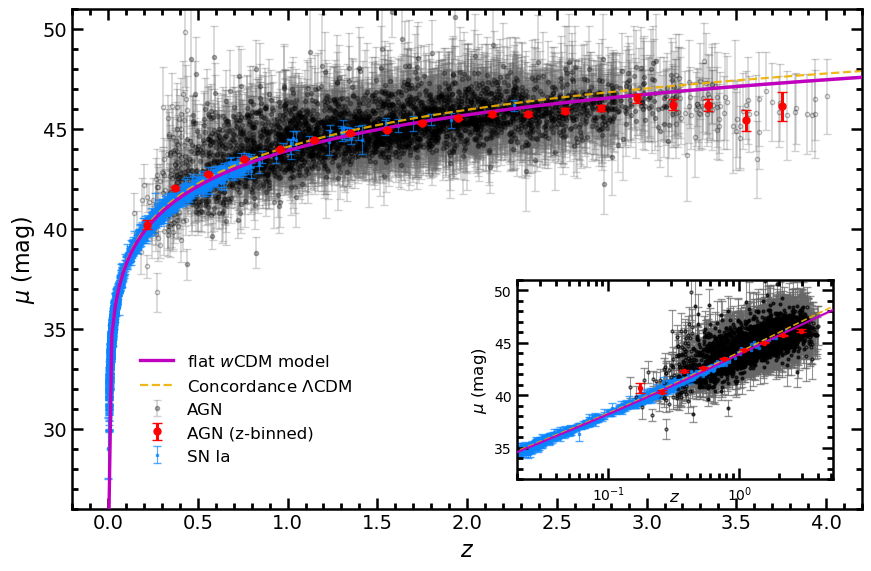

++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Outliers with residuals > 4:
	z: 0.83 | object_id: 1389193 | SDSS: 024717.29-005205.7 | RA: 41.82207 | DEC: -0.86825 | Residual: 4.6
	z: 2.76 | object_id: 1390664 | SDSS: 024328.86+003831.0 | RA: 40.87026 | DEC: 0.64196 | Residual: -4.3
	z: 0.73 | object_id: 1392713 | SDSS: 023754.67+002645.1 | RA: 39.47782 | DEC: 0.44588 | Residual: 4.5
	z: 0.59 | object_id: 1394980 | SDSS: 023121.78-000747.0 | RA: 37.84076 | DEC: -0.12975 | Residual: 6.0
	z: 1.53 | object_id: 1395413 | SDSS: 023014.79+011049.7 | RA: 37.56164 | DEC: 1.18048 | Residual: 4.0
	z: 0.49 | object_id: 1395787 | SDSS: 022914.13+010741.7 | RA: 37.30891 | DEC: 1.12826 | Residual: 4.7
	z: 1.13 | object_id: 1396458 | SDSS: 022728.66-005932.4 | RA: 36.86943 | DEC: -0.99234 | Residual: 4.6
	z: 0.38 | object_id: 1397617 | SDSS: 022414.66+002415.5 | RA: 36.06109 | DEC: 0.40431 | Residual: 4.7
	z: 0.60 | object_id: 1397913 | SDSS: 022324.21+003251.8 | RA: 35.85091 | DEC: 0.547

In [6]:
#residuals, mu_pred_median, mu_pred_std = plot_hubble(flat_samples, df_agn, df_pantheon, z_agn_pivot=z_agn_pivot, cosmo_model=cosmo_model, show=True, verbose=False, show_true=False)

debiased_residuals, _, _ = plot_hubble(flat_samples, df_agn, df_pantheon, 
                                        cosmo_model="FlatwCDM", z_pivot_agn=1.5,
                                        show_true=False, show=True, debias=True, dms=dmag_corr, plot_path='plots/hubble/test')

object_id: 1403002, sdss_name: 020929.83-005602.6
object_id: 1410326, sdss_name: 014714.24+004216.1


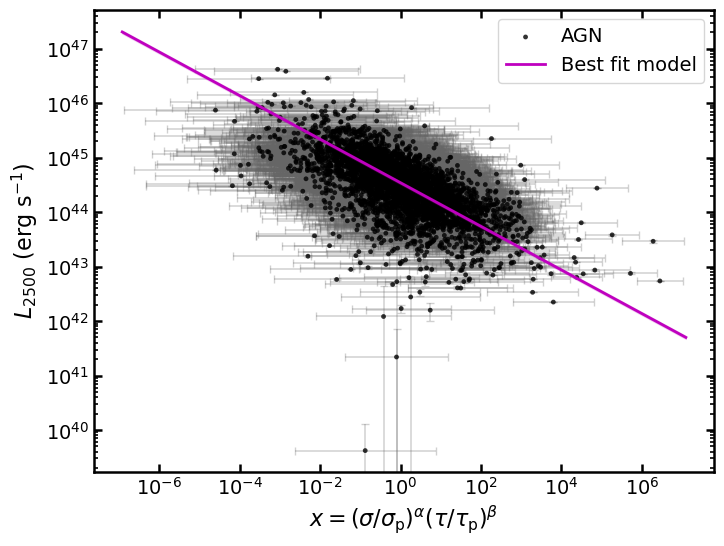

In [ ]:
def plot_predicted_L2500_vs_sigmahat(
    flat_samples, df_agn, cosmo_model, z_pivot_agn,
    plot_path='plots/hubble', show=False, debias=True, dms=None,
    show_residuals=False
):
    d = df_agn.copy()

    # --- Thinning for speed ---
    n_samples = int(flat_samples.shape[0])
    thin_factor = max(1, n_samples // 500)
    flat_samples = flat_samples[::thin_factor]

    # --- Indices & parameter names ---
    priors, model_labels, model_labels_latex = get_model_params(cosmo_model)
    param_indices = {name: model_labels.index(name) for name in model_labels}

    # --- Pack obs/errs/pivots once ---
    agn_obs_arr, agn_err_arr, agn_pivot_arr = agn_model_pack_obs(d)

    def compute_xlog_and_err(params_arr, obs_arr, err_arr, pivots_array):
        # --- params ---
        alpha_agn      = params_arr[agn_model_pidx["alpha_agn"]]
        beta_agn       = params_arr[agn_model_pidx["beta_agn"]]

        # --- observables ---
        log_sigma   = obs_arr[agn_model_oidx["log_sigma_UV"]]
        log_tau     = obs_arr[agn_model_oidx["log_tau_UV_RF"]]
        alpha_nu    = obs_arr[agn_model_oidx["alpha_nu"]]

        # --- pivots ---
        log_sigma_p = pivots_array[agn_model_oidx["log_sigma_UV"]]
        log_tau_p   = pivots_array[agn_model_oidx["log_tau_UV_RF"]]

        # Centered predictors
        dx = (log_sigma - log_sigma_p)
        dy = (log_tau   - log_tau_p)

        # --- Full predictor in log10 ---
        x_log = (
            alpha_agn * dx
            + beta_agn  * dy
        )


        x_log_err = M_model_agn_err(params_arr, obs_arr, err_arr, pivots_array)


        return x_log, x_log_err

    # --- Posterior medians (for cosmology & placing data in x) ---
    results = {key: np.median(flat_samples[:, i]) for i, key in enumerate(model_labels)}
    if cosmo_model == 'FlatwCDM':
        cosmo = FlatwCDM(H0=results['H0'], Om0=results['Om0'], w0=results['w0'])
    elif cosmo_model == 'FlatwpwaCDM':
        cosmo = FlatwpwaCDM(H0=results['H0'], Om0=results['Om0'], wp=results['wp'], wa=results['wa'], zp=z_pivot_agn)
    elif cosmo_model == 'Flatw0waCDM':
        cosmo = Flatw0waCDM(H0=results['H0'], Om0=results['Om0'], w0=results['w0'], wa=results['wa'])
    elif cosmo_model == 'FlatLambdaCDM':
        cosmo = FlatLambdaCDM(H0=results['H0'], Om0=results['Om0'])
    else:
        raise ValueError(f"Unknown cosmological model: {cosmo_model}")

    # --- y-data: log10 L_2500 (with optional debias) ---
    if debias:
        dm_interp = make_dm_function(d["apparent_mag_2500"].values, d['z'].values, dms)
        pts = np.column_stack([d['z'], d['apparent_mag_2500']])
        actual_M2500 = d['apparent_mag_2500'] - cosmo.distmod(d['z']).value
        actual_M2500 -= dm_interp(pts)
    else:
        actual_M2500 = d['apparent_mag_2500'] - cosmo.distmod(d['z']).value
    actual_logL2500 = -0.4 * (actual_M2500 - 90.0)

    # y measurement uncertainty from apparent magnitudes (propagated into log10 L)
    y_log_meas_err = 0.4 * np.asarray(d['apparent_mag_2500_err'].fillna(0.0))

    # --- x for data (full predictor) ---
    median_params_arr = agn_model_pack_params(results)
    x_log_data, x_log_err_data = compute_xlog_and_err(median_params_arr, agn_obs_arr, agn_err_arr, agn_pivot_arr)
    x_data = 10**x_log_data
    x_lower = 10**(x_log_data - x_log_err_data)
    x_upper = 10**(x_log_data + x_log_err_data)
    xerr_asym = np.vstack((x_data - np.maximum(x_lower, 1e-300),
                           np.maximum(x_upper, x_data) - x_data))

    # --- Grid for model curves/band ---
    lo = np.percentile(x_log_data - x_log_err_data, 0) - 0.05
    hi = np.percentile(x_log_data + x_log_err_data, 100) + 0.05
    x_log_grid = np.linspace(lo, hi, 200)
    x_grid = 10**x_log_grid

    # --- Predict logL on grid for each posterior sample (we'll only use quantiles + median line) ---
    ylog_grid_by_sample = []
    for s in flat_samples:
        sample_params = {k: s[param_indices[k]] for k in model_labels}
        aparr = agn_model_pack_params(sample_params)
        M0 = aparr[agn_model_pidx["M0_agn"]]
        b = -0.4 * (M0 - 90.0)
        ylog_grid_by_sample.append(b + (-0.4) * x_log_grid)

    ylog_grid_by_sample = np.asarray(ylog_grid_by_sample)  # (nsamp, ngrid)
    ylog_med  = np.median(ylog_grid_by_sample, axis=0)
    ylog_low  = np.percentile(ylog_grid_by_sample, 16, axis=0)
    ylog_high = np.percentile(ylog_grid_by_sample, 84, axis=0)

    # --- Residuals vs median model (log space) ---
    from scipy.interpolate import interp1d
    f_med  = interp1d(x_log_grid, ylog_med,  bounds_error=False, fill_value='extrapolate')
    f_low  = interp1d(x_log_grid, ylog_low,  bounds_error=False, fill_value='extrapolate')
    f_high = interp1d(x_log_grid, ylog_high, bounds_error=False, fill_value='extrapolate')

    model_logL_at_data = f_med(x_log_data)
    residuals = actual_logL2500 - model_logL_at_data

    # Error budget in log space for residuals: model spread + x-prop + mag error
    obs_err = 0.5 * (f_high(x_log_data) - f_low(x_log_data))
    propagated_err = 0.4 * np.abs(x_log_err_data)
    total_err = np.sqrt(obs_err**2 + propagated_err**2 + y_log_meas_err**2)

    # --- Figure scaffold ---
    color = 'm'
    import matplotlib.gridspec as gridspec
    if show_residuals:
        fig = plt.figure(figsize=(8, 8))
        gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)
        ax = fig.add_subplot(gs[0])
        ax_res = fig.add_subplot(gs[1], sharex=ax)
    else:
        fig, ax = plt.subplots(figsize=(8, 6))
        ax_res = None

    # --- Data with x & y error bars (y errors converted to linear space) ---
    key = 'alpha_lambda'
    color_key = d[key] if key in d.columns else np.zeros(len(d))
    yerr_linear = 10**actual_logL2500 * np.log(10) * y_log_meas_err

    ax.scatter(
        x_data, 10**actual_logL2500,
        s=12, c="black", marker="o", edgecolors="none", alpha=0.8, zorder=1, label="AGN"
    )
    ax.errorbar(
        x_data, 10**actual_logL2500, xerr=xerr_asym, yerr=yerr_linear,
        fmt='none', linestyle='none',
        ecolor="#666666", elinewidth=1.1,
        alpha=0.3, zorder=0
    )
    # --- Model: one line (median) + 68% band ---
    ax.fill_between(x_grid, 10**ylog_low, 10**ylog_high, color=color, alpha=0.18, zorder=9,)
    ax.plot(x_grid, 10**ylog_med, color=color, lw=2.0, zorder=10, label='Best fit model')

    # --- Axes & labels ---
    ax.set_ylabel(r'$L_{2500}$ (erg s$^{-1})$')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend()

    if show_residuals and ax_res is not None:
        sc = ax_res.scatter(x_data, residuals, s=10, alpha=0.7, c=color_key, cmap='bwr',
                            edgecolor='k', lw=0.5, zorder=5)
        cbar = plt.colorbar(sc, ax=ax_res, orientation='vertical'); cbar.set_label(key)
        ax_res.errorbar(x_data, residuals, yerr=total_err,
                        fmt='none', alpha=0.25, lw=1.2, capsize=2.5, capthick=1, color='k', zorder=4)
        ax_res.axhline(0, color=color, linestyle='--', zorder=3)
        ax_res.set_ylabel('Residuals (log)')
        ax_res.set_xlabel(r'$x=\sigma^\alpha\,\tau^\beta\,10^{\gamma\,\mathrm{logistic}(\alpha_\nu)}$')
        ax_res.set_xscale('log')
        ax_res.set_ylim(-2.2, 2.2)
        plt.setp(ax.get_xticklabels(), visible=False)
    else:
        ax.set_xlabel(r'$x = (\sigma/\sigma_{\mathrm{p}})^{\alpha}(\tau/\tau_{\mathrm{p}})^{\beta}$')

    os.makedirs(plot_path, exist_ok=True)
    plt.savefig(os.path.join(plot_path, "predicted_L2500_vs_fullcorr_band.png"), dpi=300)
    if show:
        plt.show()
    plt.close()

plot_predicted_L2500_vs_sigmahat(flat_samples, df_agn, debias=True, dms=dmag_corr, show_residuals=False,
                                 cosmo_model="FlatwCDM", z_pivot_agn=1.5, show=True, plot_path='plots/hubble/test')


In [ ]:
l2500 = 10**actual_logL2500


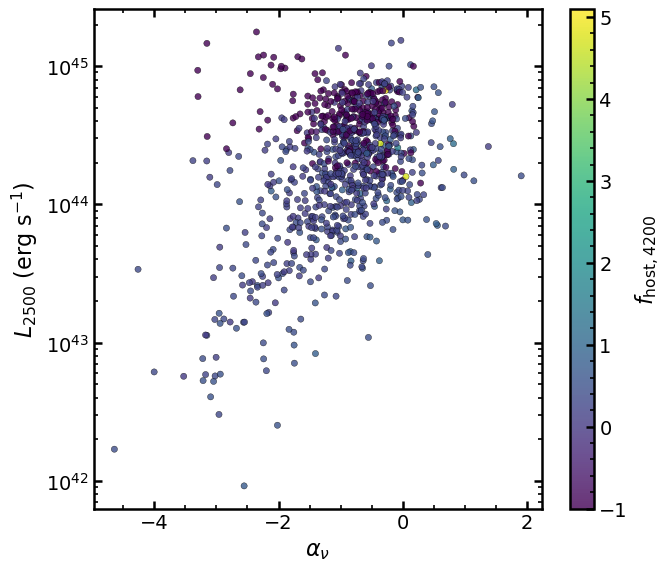

Saved plots/hubble/test/L2500_vs_alpha_nu.png


In [89]:
import numpy as np
import matplotlib.pyplot as plt
import os

import numpy as np
import matplotlib.pyplot as plt
import os

def plot_L2500_vs_alpha_nu(df_agn, cosmo_model, z_pivot_agn,
                           plot_path='plots/hubble', show=False, debias=True, dms=None):
    d = df_agn.copy()

    # --- Build cosmology ---
    if cosmo_model == 'FlatwCDM':
        cosmo = FlatwCDM(H0=70, Om0=0.3, w0=-1)   # set defaults if no posterior
    elif cosmo_model == 'FlatLambdaCDM':
        cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
    else:
        raise ValueError("Add support for your cosmology model here")

    # --- Absolute magnitudes & debias ---
    if debias:
        dm_interp = make_dm_function(d["apparent_mag_2500"].values, d['z'].values, dms)
        pts = np.column_stack([d['z'], d['apparent_mag_2500']])
        M2500 = d['apparent_mag_2500'] - cosmo.distmod(d['z']).value
        M2500 -= dm_interp(pts)
    else:
        M2500 = d['apparent_mag_2500'] - cosmo.distmod(d['z']).value

    logL2500 = -0.4 * (M2500 - 90.0)
    L2500 = 10**logL2500

    # --- Add computed L back into df for masking ---
    d = d.assign(L2500=L2500, logL2500=logL2500)

    # --- Now apply mask on f_host_4200 ---
    d = d[d['f_host_4200'] > -2].reset_index(drop=True)

    # --- Scatter plot ---
    fig, ax = plt.subplots(figsize=(7,6))
    sc = ax.scatter(d['alpha_nu'], d['L2500'], c=d['f_host_4200'], cmap='viridis',
                    s=20, alpha=0.8, edgecolor='k', lw=0.3)

    cbar = plt.colorbar(sc, ax=ax, orientation='vertical')
    cbar.set_label(r'$f_{\rm host,4200}$')

    ax.set_xlabel(r'$\alpha_\nu$')
    ax.set_ylabel(r'$L_{2500}$ (erg s$^{-1})$')
    ax.set_yscale('log')

    plt.tight_layout()
    os.makedirs(plot_path, exist_ok=True)
    outfile = os.path.join(plot_path, "L2500_vs_alpha_nu.png")
    plt.savefig(outfile, dpi=300)
    if show:
        plt.show()
    plt.close()
    print(f"Saved {outfile}")

plot_L2500_vs_alpha_nu(df_agn, cosmo_model="FlatwCDM", z_pivot_agn=1.5, debias=True, dms=dmag_corr, show=True, plot_path='plots/hubble/test')

In [91]:
df_agn.loc[df_agn['alpha_lambda'] > 0].sort_values(by='alpha_lambda', ascending=False)
df_agn.loc[df_agn['alpha_lambda'] > 0].sort_values(by='alpha_lambda', ascending=False).to_csv('alpha_lambda_gt0.csv', index=False)

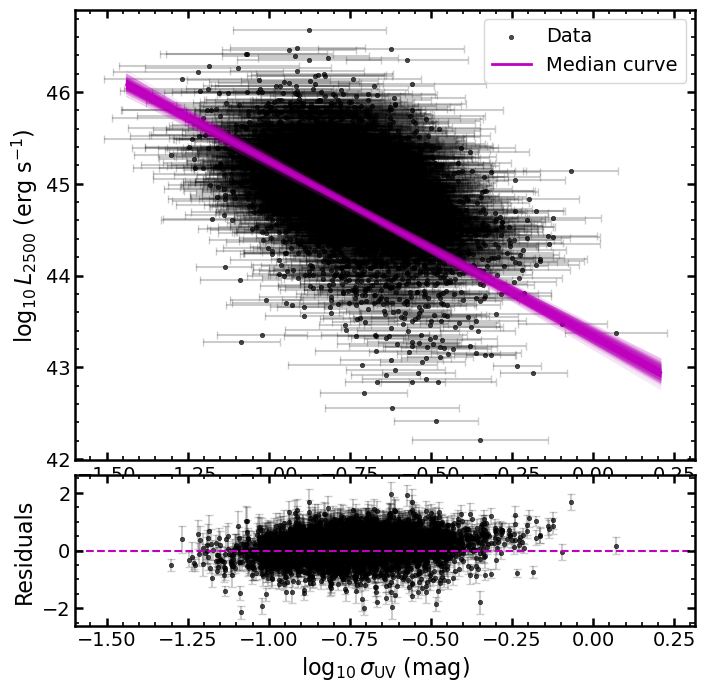

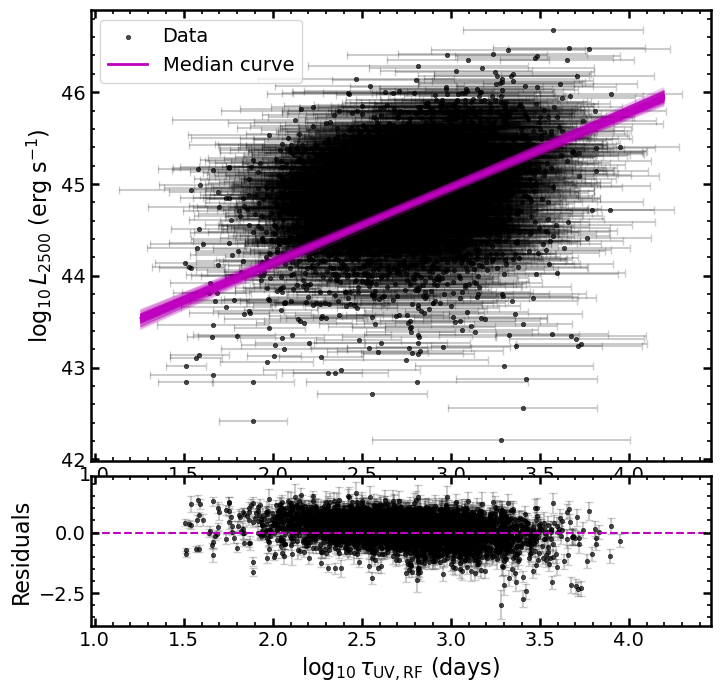

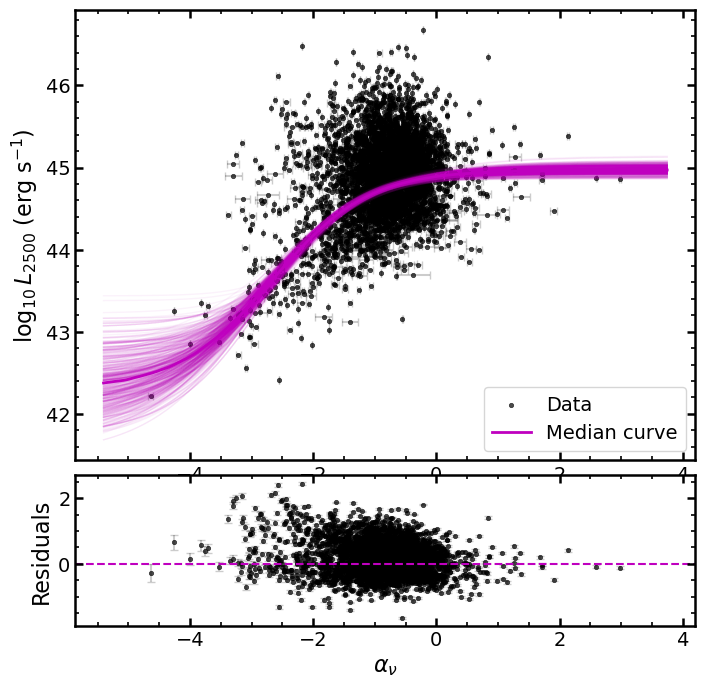

In [41]:
def plot_predicted_L2500_vs_raw_observables(
    flat_samples, df_agn, cosmo_model, z_pivot_agn,
    plot_path='plots/hubble', show=False, max_lines=600
):
    """
    Make 3 figures with one line per posterior sample (low alpha):
      1) log10 L2500 vs log_sigma_UV   (slope ~ -0.4*alpha)
      2) log10 L2500 vs log_tau_UV_RF  (slope ~ -0.4*beta)
      3) log10 L2500 vs alpha_nu       (curved: -0.4*gamma * logistic(alpha_nu))
    Other observables are fixed to their sample-median values.
    Residual panels compare data to the *median* model curve in each panel.
    """
    d = df_agn.copy()

    # --- Thinning for speed ---
    n_samples = int(flat_samples.shape[0])
    thin_factor = max(1, n_samples // 500)
    flat_samples = flat_samples[::thin_factor]

    # --- Param indexing ---
    priors, model_labels, model_labels_latex = get_model_params(cosmo_model)
    param_indices = {name: model_labels.index(name) for name in model_labels}

    # --- Pack obs/errs/pivots arrays once ---
    agn_obs_arr, agn_err_arr, agn_pivot_arr = agn_model_pack_obs(d)

    # Convenience local getters
    def _get(name):  return agn_model_pidx[name]
    def _oidx(name): return agn_model_oidx[name]
    def _eidx(name): return agn_model_eidx[name]

    # --- Posterior medians (used for cosmology and for "fixed" values of the other observables) ---
    results = {key: np.median(flat_samples[:, i]) for i, key in enumerate(model_labels)}
    median_params_arr = agn_model_pack_params(results)

    # Cosmology
    if cosmo_model == 'FlatwCDM':
        cosmo = FlatwCDM(H0=results['H0'], Om0=results['Om0'], w0=results['w0'])
    elif cosmo_model == 'FlatwpwaCDM':
        cosmo = FlatwpwaCDM(H0=results['H0'], Om0=results['Om0'], wp=results['wp'], wa=results['wa'], zp=z_pivot_agn)
    elif cosmo_model == 'Flatw0waCDM':
        cosmo = Flatw0waCDM(H0=results['H0'], Om0=results['Om0'], w0=results['w0'], wa=results['wa'])
    elif cosmo_model == 'FlatLambdaCDM':
        cosmo = FlatLambdaCDM(H0=results['H0'], Om0=results['Om0'])
    else:
        raise ValueError(f"Unknown cosmological model: {cosmo_model}")

    # Data: log10 L_2500
    actual_M2500 = d['apparent_mag_2500'] - cosmo.distmod(d['z']).value
    actual_logL2500 = -0.4 * (actual_M2500 - 90.0)

    # Fixed values (medians of the dataset) for the "other" observables in each panel
    log_sigma_fixed = np.median(d['log_sigma_UV'])
    log_tau_fixed   = np.median(d['log_tau_UV_RF'])
    alpha_nu_fixed  = np.median(d['alpha_nu'])

    # Errors for x (data)
    log_sigma_err = d['log_sigma_UV_err']
    log_tau_err   = d['log_tau_UV_RF_err']
    alpha_nu_err  = d['alpha_nu_err']

    # Pivots
    log_sigma_p = agn_pivot_arr[_oidx("log_sigma_UV")]
    log_tau_p   = agn_pivot_arr[_oidx("log_tau_UV_RF")]

    # Helper: logistic and derivative
    def _logistic(alpha_nu, k_logistic, alpha_nu_pivot):
        z = k_logistic * (alpha_nu - alpha_nu_pivot)
        return 2*expit(z) - 1

    def _logistic_deriv(alpha_nu, k_logistic, alpha_nu_pivot):
        z = k_logistic * (alpha_nu - alpha_nu_pivot)
        sig = expit(z)
        return k_logistic * sig * (1.0 - sig)

    # --- Panel builders -------------------------------------------------------

    def _draw_panel(
        xname, xgrid, xdata, xerr,
        vary_which="sigma",  # "sigma" | "tau" | "alpha_nu"
        fname="panel.png",
        xlabel=r"$x$",
    ):
        """
        Draw one panel: many sample lines (low alpha) + data scatter + residuals.
        For each sample, the prediction is:
          logL = -0.4*(M0 - 90) - 0.4 * [alpha*(logσ-logσp) + beta*(logτ-logτp) + gamma*logistic(α_ν)]
        where only one observable varies along xgrid; the others are fixed to medians.
        """
        color = 'm'
        import matplotlib.gridspec as gridspec
        fig = plt.figure(figsize=(8, 8))
        gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)
        ax = fig.add_subplot(gs[0])
        ax_res = fig.add_subplot(gs[1], sharex=ax)

        # Precompute sample curves for uncertainty envelope at each x (for residual error bars)
        ygrid_samples = []

        # Draw sample lines
        nplot = min(max_lines, flat_samples.shape[0])
        for i, s in enumerate(flat_samples):
            sample_params = {k: s[param_indices[k]] for k in model_labels}
            aparr = agn_model_pack_params(sample_params)

            M0       = aparr[_get("M0_agn")]
            alpha    = aparr[_get("alpha_agn")]
            beta     = aparr[_get("beta_agn")]
            gamma    = aparr[_get("gamma_agn")]
            klog     = aparr[_get("k_logistic")]
            a_pivot  = aparr[_get("alpha_nu_pivot")]

            # Choose which observable varies along xgrid
            if vary_which == "sigma":
                log_sigma = xgrid
                log_tau   = log_tau_fixed
                a_nu      = alpha_nu_fixed
            elif vary_which == "tau":
                log_sigma = log_sigma_fixed
                log_tau   = xgrid
                a_nu      = alpha_nu_fixed
            elif vary_which == "alpha_nu":
                log_sigma = log_sigma_fixed
                log_tau   = log_tau_fixed
                a_nu      = xgrid
            else:
                raise ValueError("vary_which must be 'sigma', 'tau', or 'alpha_nu'.")

            # Build model in log space along the grid
            xlog_combo = (
                alpha * (log_sigma - log_sigma_p)
                + beta  * (log_tau   - log_tau_p)
                + gamma * _logistic(a_nu, klog, a_pivot)
            )
            ygrid = -0.4 * (M0 - 90.0) - 0.4 * xlog_combo
            ygrid_samples.append(ygrid)

            # Draw one line per sample (alpha transparency)
            if i < nplot:
                ax.plot(xgrid, ygrid, color=color, alpha=0.05, lw=1.0, zorder=-6)

        ygrid_samples = np.asarray(ygrid_samples)  # (nsamp, ngrid)
        ygrid_med  = np.median(ygrid_samples, axis=0)
        ygrid_low  = np.percentile(ygrid_samples, 16, axis=0)
        ygrid_high = np.percentile(ygrid_samples, 84, axis=0)

        # Residuals w.r.t. the median curve evaluated at data x
        from scipy.interpolate import interp1d
        f_med = interp1d(xgrid, ygrid_med, bounds_error=False, fill_value='extrapolate')
        y_model_at_data = f_med(xdata)
        residuals = actual_logL2500 - y_model_at_data

        # y-uncertainty from sample spread at each data x
        f_low  = interp1d(xgrid, ygrid_low,  bounds_error=False, fill_value='extrapolate')
        f_high = interp1d(xgrid, ygrid_high, bounds_error=False, fill_value='extrapolate')
        obs_err = 0.5 * (f_high(xdata) - f_low(xdata))

        # Propagate x-uncertainty into y using the *median* slope for that panel
        alpha_med = median_params_arr[_get("alpha_agn")]
        beta_med  = median_params_arr[_get("beta_agn")]
        gamma_med = median_params_arr[_get("gamma_agn")]
        klog_med  = median_params_arr[_get("k_logistic")]
        a_piv_med = median_params_arr[_get("alpha_nu_pivot")]

        if vary_which == "sigma":
            dydx = -0.4 * alpha_med                    # d logL / d (logσ)
        elif vary_which == "tau":
            dydx = -0.4 * beta_med                     # d logL / d (logτ)
        else:  # alpha_nu
            dlogistic = _logistic_deriv(xdata, klog_med, a_piv_med)
            dydx = -0.4 * gamma_med * dlogistic        # d logL / d (alpha_nu)

        propagated_err = np.abs(dydx) * xerr
        total_err = np.sqrt(obs_err**2 + propagated_err**2)

        # --- Draw data (in log space on y; x is linear in the raw variable) ---
        ax.scatter(xdata, actual_logL2500, label='Data',
                   s=10, alpha=0.7, edgecolor='k', facecolor='k', lw=0.5, zorder=-8)
        ax.errorbar(xdata, actual_logL2500, xerr=xerr,
                    fmt='none', alpha=0.2, lw=1.5, capsize=3, capthick=1, color='k', zorder=-9)

        # Optional: median curve on top for reference
        ax.plot(xgrid, ygrid_med, color=color, lw=2.0, zorder=-5, label='Median curve')

        ax.set_ylabel(r'$\log_{10} L_{2500}$ (erg s$^{-1}$)')
        ax.legend(loc='best')

        # Residuals
        ax_res.scatter(xdata, residuals, s=10, alpha=0.7,
                       edgecolor='k', facecolor='k', lw=0.5, zorder=-10)
        ax_res.errorbar(xdata, residuals, yerr=total_err,
                        fmt='none', alpha=0.2, lw=1.5, capsize=3, capthick=1, color='k', zorder=-11)
        ax_res.axhline(0, color=color, linestyle='--', zorder=-9)
        ax_res.set_ylabel('Residuals')
        ax_res.set_xlabel(xlabel)

        # Save
        os.makedirs(plot_path, exist_ok=True)
        plt.setp(ax.get_xticklabels(), visible=True)  # x is linear here
        plt.savefig(os.path.join(plot_path, fname), dpi=300)
        if show:
            plt.show()
        plt.close()

    # --- Build sensible grids spanning the data range with padding ---
    pad_sigma = 0.1 * (d['log_sigma_UV'].max() - d['log_sigma_UV'].min() + 1e-6)
    pad_tau   = 0.1 * (d['log_tau_UV_RF'].max() - d['log_tau_UV_RF'].min() + 1e-6)
    pad_an    = 0.1 * (d['alpha_nu'].max() - d['alpha_nu'].min() + 1e-6)

    grid_sigma = np.linspace(d['log_sigma_UV'].min() - pad_sigma, d['log_sigma_UV'].max() + pad_sigma, 200)
    grid_tau   = np.linspace(d['log_tau_UV_RF'].min() - pad_tau, d['log_tau_UV_RF'].max() + pad_tau, 200)
    grid_an    = np.linspace(d['alpha_nu'].min() - pad_an, d['alpha_nu'].max() + pad_an, 200)

    # --- Draw each panel ---
    _draw_panel(
        xname='log_sigma_UV', xgrid=grid_sigma,
        xdata=d['log_sigma_UV'].values, xerr=log_sigma_err.values,
        vary_which="sigma",
        fname="predicted_logL2500_vs_logsigma_samples.png",
        xlabel=r'$\log_{10}\sigma_{\mathrm{UV}}$ (mag)'
    )

    _draw_panel(
        xname='log_tau_UV_RF', xgrid=grid_tau,
        xdata=d['log_tau_UV_RF'].values, xerr=log_tau_err.values,
        vary_which="tau",
        fname="predicted_logL2500_vs_logtau_samples.png",
        xlabel=r'$\log_{10}\tau_{\mathrm{UV,RF}}$ (days)'
    )

    _draw_panel(
        xname='alpha_nu', xgrid=grid_an,
        xdata=d['alpha_nu'].values, xerr=alpha_nu_err.values,
        vary_which="alpha_nu",
        fname="predicted_logL2500_vs_alphanu_samples.png",
        xlabel=r'$\alpha_\nu$'
    )

plot_predicted_L2500_vs_raw_observables(
    flat_samples, df_agn, cosmo_model="FlatwCDM", z_pivot_agn=1.5,
    show=True, plot_path='plots/hubble/test')